In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df2 = df.copy()

In [4]:
df2.T

,0,1,2,3,4,5,6,7,8,9,...,881,882,883,884,885,886,887,888,889,890
PassengerId,1,2,3,4,5,6,7,8,9,10,...,882,883,884,885,886,887,888,889,890,891
Survived,0,1,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,1,0,1,0
Pclass,3,1,3,1,3,3,1,3,3,2,...,3,3,2,3,3,2,1,3,1,3
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th...","Heikkinen, Miss. Laina","Futrelle, Mrs. Jacques Heath (Lily May Peel)","Allen, Mr. William Henry","Moran, Mr. James","McCarthy, Mr. Timothy J","Palsson, Master. Gosta Leonard","Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)","Nasser, Mrs. Nicholas (Adele Achem)",...,"Markun, Mr. Johann","Dahlberg, Miss. Gerda Ulrika","Banfield, Mr. Frederick James","Sutehall, Mr. Henry Jr","Rice, Mrs. William (Margaret Norton)","Montvila, Rev. Juozas","Graham, Miss. Margaret Edith","Johnston, Miss. Catherine Helen ""Carrie""","Behr, Mr. Karl Howell","Dooley, Mr. Patrick"
Sex,male,female,female,female,male,male,male,male,female,female,...,male,female,male,male,female,male,female,female,male,male
Age,22.0,38.0,26.0,35.0,35.0,NaN,54.0,2.0,27.0,14.0,...,33.0,22.0,28.0,25.0,39.0,27.0,19.0,NaN,26.0,32.0
SibSp,1,1,0,1,0,0,0,3,0,1,...,0,0,0,0,0,0,0,1,0,0
Parch,0,0,0,0,0,0,0,1,2,0,...,0,0,0,0,5,0,0,2,0,0
Ticket,A/5 21171,PC 17599,STON/O2. 3101282,113803,373450,330877,17463,349909,347742,237736,...,349257,7552,C.A./SOTON 34068,SOTON/OQ 392076,382652,211536,112053,W./C. 6607,111369,370376
Fare,7.25,71.2833,7.925,53.1,8.05,8.4583,51.8625,21.075,11.1333,30.0708,...,7.8958,10.5167,10.5,7.05,29.125,13.0,30.0,23.45,30.0,7.75


In [5]:
df2['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

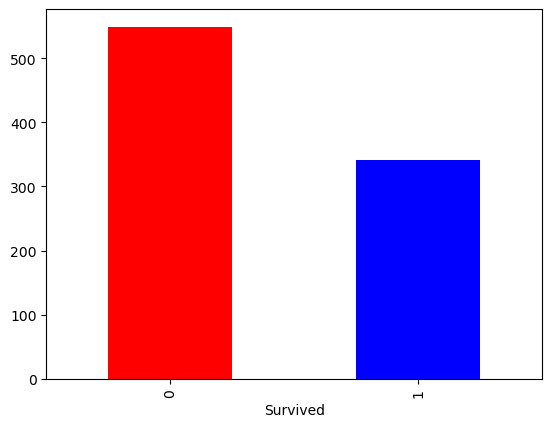

In [6]:
df2['Survived'].value_counts().plot(kind = 'bar', color = ['red', 'blue']);

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df2.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df2['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [10]:
df2['Age'].isna().sum()

np.int64(0)

In [11]:
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

In [12]:
df2['Embarked'].isna().sum()

np.int64(0)

In [13]:
df2['Has_Cabin'] = df2['Cabin'].notna().astype(int)
df2['Deck'] = df2['Cabin'].astype(str).str[0].replace('nan', 'U')

In [14]:
df2 = df2.drop('Cabin', axis=1)

In [15]:
df2.T

,0,1,2,3,4,5,6,7,8,9,...,881,882,883,884,885,886,887,888,889,890
PassengerId,1,2,3,4,5,6,7,8,9,10,...,882,883,884,885,886,887,888,889,890,891
Survived,0,1,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,1,0,1,0
Pclass,3,1,3,1,3,3,1,3,3,2,...,3,3,2,3,3,2,1,3,1,3
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th...","Heikkinen, Miss. Laina","Futrelle, Mrs. Jacques Heath (Lily May Peel)","Allen, Mr. William Henry","Moran, Mr. James","McCarthy, Mr. Timothy J","Palsson, Master. Gosta Leonard","Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)","Nasser, Mrs. Nicholas (Adele Achem)",...,"Markun, Mr. Johann","Dahlberg, Miss. Gerda Ulrika","Banfield, Mr. Frederick James","Sutehall, Mr. Henry Jr","Rice, Mrs. William (Margaret Norton)","Montvila, Rev. Juozas","Graham, Miss. Margaret Edith","Johnston, Miss. Catherine Helen ""Carrie""","Behr, Mr. Karl Howell","Dooley, Mr. Patrick"
Sex,male,female,female,female,male,male,male,male,female,female,...,male,female,male,male,female,male,female,female,male,male
Age,22.0,38.0,26.0,35.0,35.0,25.0,54.0,2.0,27.0,14.0,...,33.0,22.0,28.0,25.0,39.0,27.0,19.0,21.5,26.0,32.0
SibSp,1,1,0,1,0,0,0,3,0,1,...,0,0,0,0,0,0,0,1,0,0
Parch,0,0,0,0,0,0,0,1,2,0,...,0,0,0,0,5,0,0,2,0,0
Ticket,A/5 21171,PC 17599,STON/O2. 3101282,113803,373450,330877,17463,349909,347742,237736,...,349257,7552,C.A./SOTON 34068,SOTON/OQ 392076,382652,211536,112053,W./C. 6607,111369,370376
Fare,7.25,71.2833,7.925,53.1,8.05,8.4583,51.8625,21.075,11.1333,30.0708,...,7.8958,10.5167,10.5,7.05,29.125,13.0,30.0,23.45,30.0,7.75


In [16]:
df2 = df2.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   891 non-null    int64  
 1   Pclass     891 non-null    int64  
 2   Sex        891 non-null    object 
 3   Age        891 non-null    float64
 4   SibSp      891 non-null    int64  
 5   Parch      891 non-null    int64  
 6   Fare       891 non-null    float64
 7   Embarked   891 non-null    object 
 8   Has_Cabin  891 non-null    int64  
 9   Deck       891 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [18]:
df2.isna().sum()

Survived     0
Pclass       0
Sex          0
Age          0
SibSp        0
Parch        0
Fare         0
Embarked     0
Has_Cabin    0
Deck         0
dtype: int64

In [19]:
for label, content in df2.items():
    if pd.api.types.is_object_dtype(content):
        print(label)

Sex
Embarked
Deck


In [20]:
for label, content in df2.items():
    if pd.api.types.is_object_dtype(content):
        df2[label] = content.astype('category')

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Survived   891 non-null    int64   
 1   Pclass     891 non-null    int64   
 2   Sex        891 non-null    category
 3   Age        891 non-null    float64 
 4   SibSp      891 non-null    int64   
 5   Parch      891 non-null    int64   
 6   Fare       891 non-null    float64 
 7   Embarked   891 non-null    category
 8   Has_Cabin  891 non-null    int64   
 9   Deck       891 non-null    category
dtypes: category(3), float64(2), int64(5)
memory usage: 52.1 KB


In [22]:
for label, content in df2.items():
    if not pd.api.types.is_numeric_dtype(content):
        df2[label] = pd.Categorical(content).codes + 1 

In [23]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   891 non-null    int64  
 1   Pclass     891 non-null    int64  
 2   Sex        891 non-null    int8   
 3   Age        891 non-null    float64
 4   SibSp      891 non-null    int64  
 5   Parch      891 non-null    int64  
 6   Fare       891 non-null    float64
 7   Embarked   891 non-null    int8   
 8   Has_Cabin  891 non-null    int64  
 9   Deck       891 non-null    int8   
dtypes: float64(2), int64(5), int8(3)
memory usage: 51.5 KB


In [24]:
df2.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Deck
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,1.647587,29.112424,0.523008,0.381594,32.204208,2.536476,0.228956,7.716049
std,0.486592,0.836071,0.477990,13.304424,1.102743,0.806057,49.693429,0.791503,0.420397,2.460739
min,0.000000,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,2.000000,1.000000,21.500000,0.000000,0.000000,7.910400,2.000000,0.000000,9.000000
50%,0.000000,3.000000,2.000000,26.000000,0.000000,0.000000,14.454200,3.000000,0.000000,9.000000
75%,1.000000,3.000000,2.000000,36.000000,1.000000,0.000000,31.000000,3.000000,0.000000,9.000000
max,1.000000,3.000000,2.000000,80.000000,8.000000,6.000000,512.329200,3.000000,1.000000,9.000000


In [25]:
df2['Sex'].value_counts()

Sex
2    577
1    314
Name: count, dtype: int64

In [26]:
# compare Survived column with Sex column
pd.crosstab(df2['Survived'], df2['Sex'])

Sex,1,2
Survived,,
0,81,468
1,233,109


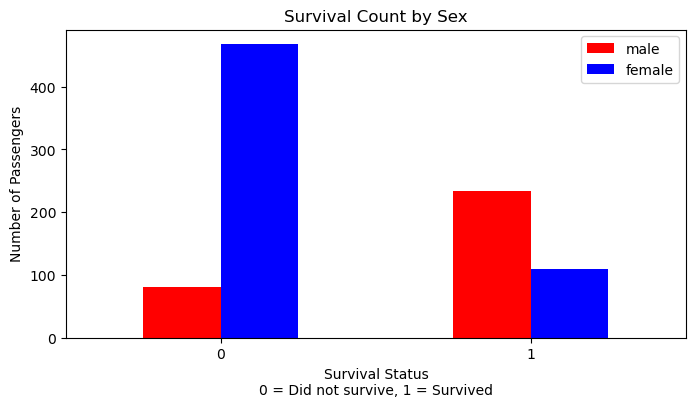

In [27]:
pd.crosstab(df2['Survived'], df2['Sex']).plot(
    kind='bar', 
    figsize=(8, 4), 
    color=['red', 'blue']
)
plt.title('Survival Count by Sex')
plt.xlabel('Survival Status\n0 = Did not survive, 1 = Survived')
plt.ylabel('Number of Passengers')
plt.legend(['male', 'female'])
plt.xticks(rotation=0)
plt.show()

In [28]:
# compare Survived column with Passenger class column
pd.crosstab(df2['Survived'], df2['Pclass'])

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


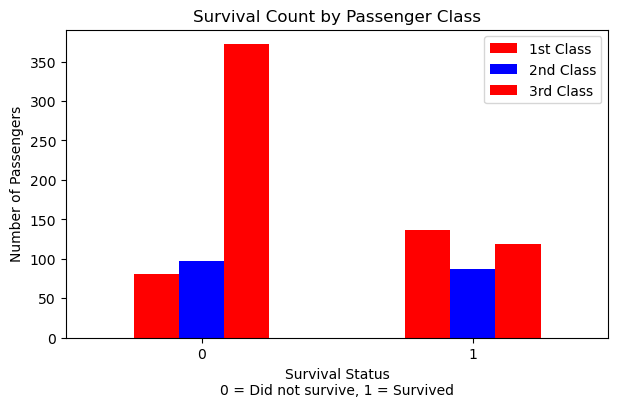

In [29]:
pd.crosstab(df2['Survived'], df2['Pclass']).plot(kind='bar', color=['red', 'blue'], figsize=(7, 4))
plt.title('Survival Count by Passenger Class')
plt.xlabel('Survival Status\n0 = Did not survive, 1 = Survived')
plt.ylabel('Number of Passengers')
plt.legend(['1st Class', '2nd Class', '3rd Class'])
plt.xticks(rotation=0)
plt.show()

In [30]:
# compare Survived column with Embarked column
pd.crosstab(df2['Survived'], df2['Embarked'])

Embarked,1,2,3
Survived,,,
0,75,47,427
1,93,30,219


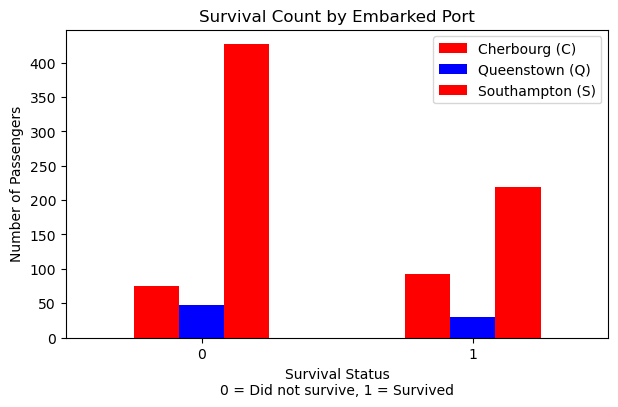

In [31]:
pd.crosstab(df2['Survived'], df2['Embarked']).plot(kind='bar', color=['red', 'blue'], figsize=(7, 4))
plt.title('Survival Count by Embarked Port')
plt.xlabel('Survival Status\n0 = Did not survive, 1 = Survived')
plt.ylabel('Number of Passengers')
plt.legend(['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])
plt.xticks(rotation=0)
plt.show()

In [32]:
# compare Survived column with Age column
pd.crosstab(df2['Survived'], df2['Age'])

Age,0.42,0.67,0.75,0.83,0.92,1.00,2.00,3.00,4.00,5.00,...,62.00,63.00,64.00,65.00,66.00,70.00,70.50,71.00,74.00,80.00
Survived,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,2,7,1,3,0,...,2,0,2,3,1,2,1,2,1,0
1,1,1,2,2,1,5,3,5,7,4,...,2,2,0,0,0,0,0,0,0,1


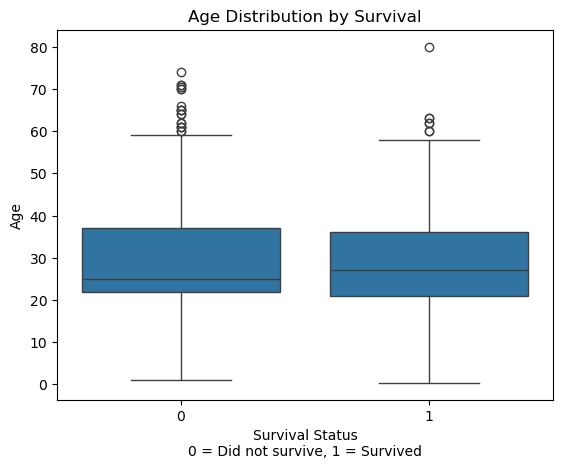

In [33]:
import seaborn as sns

sns.boxplot(x='Survived', y='Age', data=df2)
plt.title('Age Distribution by Survival')
plt.xlabel('Survival Status\n0 = Did not survive, 1 = Survived')
plt.ylabel('Age')
plt.show()

In [34]:
# compare Survived column with Has_Cabin column
pd.crosstab(df2['Survived'], df2['Has_Cabin'])

Has_Cabin,0,1
Survived,,
0,481,68
1,206,136


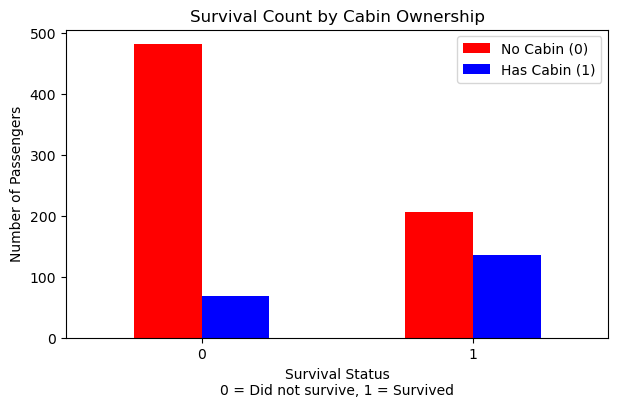

In [35]:
pd.crosstab(df2['Survived'], df2['Has_Cabin']).plot(kind='bar', color=['red', 'blue'], figsize=(7, 4))
plt.title('Survival Count by Cabin Ownership')
plt.xlabel('Survival Status\n0 = Did not survive, 1 = Survived')
plt.ylabel('Number of Passengers')
plt.legend(['No Cabin (0)', 'Has Cabin (1)'])
plt.xticks(rotation=0)
plt.show()

In [36]:
df2.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Deck
0,0,3,2,22.0,1,0,7.2500,3,0,9
1,1,1,1,38.0,1,0,71.2833,1,1,3
2,1,3,1,26.0,0,0,7.9250,3,0,9
3,1,1,1,35.0,1,0,53.1000,3,1,3
4,0,3,2,35.0,0,0,8.0500,3,0,9


In [37]:
# make a corellation matrix
df2.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Deck
Survived,1.000000,-0.338481,-0.543351,-0.059579,-0.035322,0.081629,0.257307,-0.167675,0.316912,-0.301116
Pclass,-0.338481,1.000000,0.131900,-0.413583,0.083081,0.018443,-0.549500,0.162098,-0.725541,0.746616
Sex,-0.543351,0.131900,1.000000,0.102706,-0.114631,-0.245489,-0.182333,0.108262,-0.140391,0.123076
Age,-0.059579,-0.413583,0.102706,1.000000,-0.249854,-0.175526,0.122692,-0.007833,0.277022,-0.295493
SibSp,-0.035322,0.083081,-0.114631,-0.249854,1.000000,0.414838,0.159651,0.068230,-0.040460,0.041540
Parch,0.081629,0.018443,-0.245489,-0.175526,0.414838,1.000000,0.216225,0.039798,0.036987,-0.032548
Fare,0.257307,-0.549500,-0.182333,0.122692,0.159651,0.216225,1.000000,-0.224719,0.482075,-0.523013
Embarked,-0.167675,0.162098,0.108262,-0.007833,0.068230,0.039798,-0.224719,1.000000,-0.160196,0.194255
Has_Cabin,0.316912,-0.725541,-0.140391,0.277022,-0.040460,0.036987,0.482075,-0.160196,1.000000,-0.958054
Deck,-0.301116,0.746616,0.123076,-0.295493,0.041540,-0.032548,-0.523013,0.194255,-0.958054,1.000000


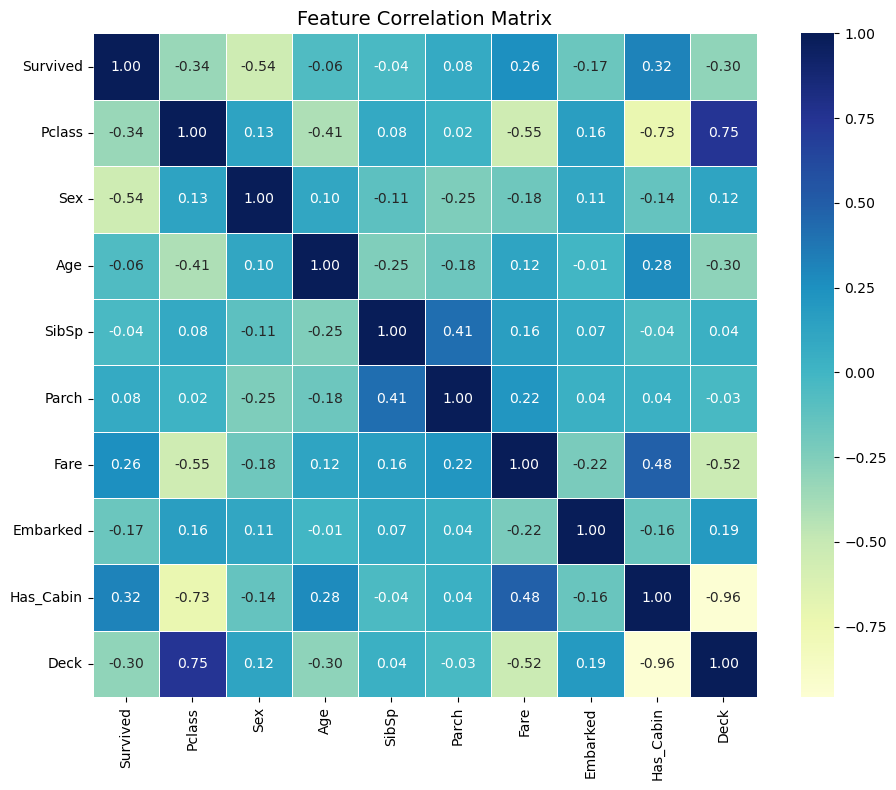

In [38]:
corr_matrix = df2.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    linewidths=0.5, 
    fmt='.2f', 
    cmap='YlGnBu',
    center=0,
    square=True
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()

In [40]:
df2.to_csv('titanic_cleaned2.csv', index=False)

In [41]:
# split data into x and y
x = df2.drop('Survived', axis = 1)
y = df2['Survived']

In [42]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Deck
0,3,2,22.0,1,0,7.2500,3,0,9
1,1,1,38.0,1,0,71.2833,1,1,3
2,3,1,26.0,0,0,7.9250,3,0,9
3,1,1,35.0,1,0,53.1000,3,1,3
4,3,2,35.0,0,0,8.0500,3,0,9
...,...,...,...,...,...,...,...,...,...
886,2,2,27.0,0,0,13.0000,3,0,9
887,1,1,19.0,0,0,30.0000,3,1,2
888,3,1,21.5,1,2,23.4500,3,0,9
889,1,2,26.0,0,0,30.0000,1,1,3


In [43]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [44]:
# importing the models from scikit-learn

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# model evaluations

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [45]:
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [46]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Deck
331,1,2,45.5,0,0,28.5000,3,1,3
733,2,2,23.0,0,0,13.0000,3,0,9
382,3,2,32.0,0,0,7.9250,3,0,9
704,3,2,26.0,1,0,7.8542,3,0,9
813,3,1,6.0,4,2,31.2750,3,0,9
...,...,...,...,...,...,...,...,...,...
106,3,1,21.0,0,0,7.6500,3,0,9
270,1,2,40.0,0,0,31.0000,3,0,9
860,3,2,41.0,2,0,14.1083,3,0,9
435,1,1,14.0,1,2,120.0000,3,1,2


In [47]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Deck
709,3,2,25.0,1,1,15.2458,1,0,9
439,2,2,31.0,0,0,10.5000,3,0,9
840,3,2,20.0,0,0,7.9250,3,0,9
720,2,1,6.0,0,1,33.0000,3,0,9
39,3,1,14.0,1,0,11.2417,1,0,9
...,...,...,...,...,...,...,...,...,...
433,3,2,17.0,0,0,7.1250,3,0,9
773,3,2,25.0,0,0,7.2250,1,0,9
25,3,1,38.0,1,5,31.3875,3,0,9
84,2,1,17.0,0,0,10.5000,3,0,9


In [48]:
models = {'Logistic Regression': LogisticRegression(),
          'KNN': KNeighborsClassifier(),
           'Random forest': RandomForestClassifier()}

def fit_and_score(models, x_train, x_test, y_train, y_test):
    '''
    Fits and evaluates given machine learning models.
    models : a dict of different scikit learn machine learning models
    x_train : training data (no labels)
    x_test : testing data (no labels)
    y_train : training labels
    y_test : testing labels
    '''
    np.random.seed(42)

    model_scores = {}

    for name , model in models.items():
        
        model.fit(x_train, y_train)

        model_scores[name] = model.score(x_test, y_test)
        
    return model_scores

In [49]:
model_scores = fit_and_score(models = models,
                             x_train = x_train,
                             x_test = x_test,
                             y_train = y_train,
                             y_test = y_test)
model_scores

C:\Users\adeku\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8156424581005587,
 'KNN': 0.7262569832402235,
 'Random forest': 0.8212290502793296}

In [50]:
model_compare = pd.DataFrame(model_scores, index = ['Acurracy'])
model_compare

,Logistic Regression,KNN,Random forest
Acurracy,0.815642,0.726257,0.821229


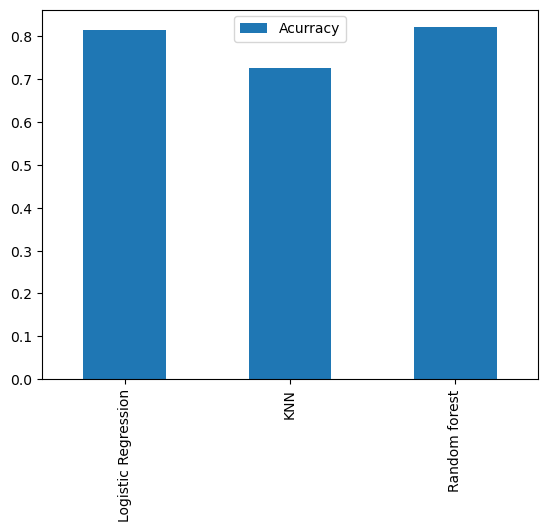

In [51]:
model_compare.T.plot(kind = 'bar');

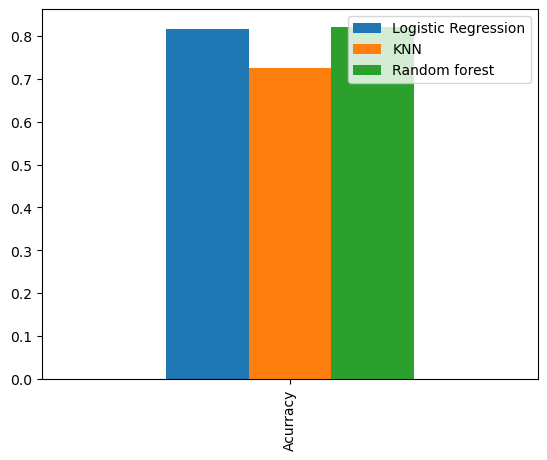

In [52]:
model_compare.plot(kind = 'bar');

In [53]:
# create a hyperparameter grid for logisticregression
log_reg_grid = {'C': np.logspace(-4, 4, 20),
                'solver': ['liblinear']}

# create a hyperparameter grid for RandomForestClassifier
rf_grid = {'n_estimators': np.arange(10, 1000, 50),
           'max_depth': [None, 3, 5, 10],
            'min_samples_split': np.arange(2, 20, 2),
            'min_samples_leaf': np.arange(1, 20, 2)}

In [54]:
# Tune logistic regression 
np.random.seed()

# setup random hyperparameter search for LogisticRegression

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions = log_reg_grid,
                                cv = 5,
                                n_iter = 20,
                                verbose = True)

# fit random hyperparameter search model for LogisticRegression

rs_log_reg.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [55]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.615848211066026)}

In [56]:
rs_log_reg.score(x_test, y_test)

0.8100558659217877

In [57]:
np.random.seed(42)


rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions = rf_grid,
                           cv = 5,
                           n_iter = 20,
                           verbose = True)

rs_rf.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [58]:
rs_rf.best_params_

{'n_estimators': np.int64(510),
 'min_samples_split': np.int64(14),
 'min_samples_leaf': np.int64(1),
 'max_depth': None}

In [59]:
rs_rf.score(x_test, y_test)

0.8100558659217877

In [60]:
log_reg_grid = {'C': np.logspace(-4, 4, 30),
                'solver': ['liblinear']}

np.random.seed()


gs_log_reg = GridSearchCV(LogisticRegression(),
                                param_grid = log_reg_grid,
                                cv = 5,
                                verbose = True)

gs_log_reg.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [61]:
gs_log_reg.best_params_

{'C': np.float64(9.236708571873866), 'solver': 'liblinear'}

In [62]:
gs_log_reg.score(x_test, y_test)

0.8156424581005587

In [63]:
y_preds = gs_log_reg.predict(x_test)
y_preds

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1])

In [64]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

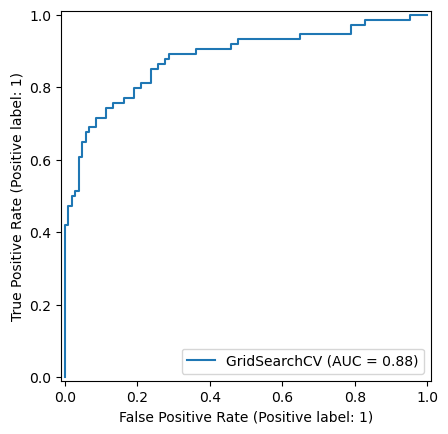

In [65]:
RocCurveDisplay.from_estimator(estimator = gs_log_reg, X = x_test, y = y_test);

In [66]:
print(confusion_matrix(y_test, y_preds))

[[91 14]
 [19 55]]


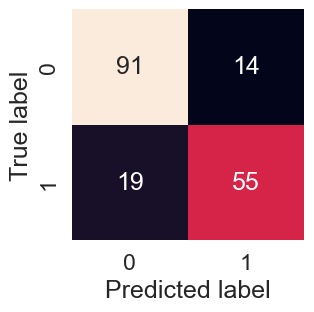

In [67]:
sns.set(font_scale = 1.5)
def plot_conf_mat(y_test, y_preds):
    '''
    plot a nice looking confusion matrix using seaborn heatmap()
    '''
    fig, ax = plt.subplots(figsize = (3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot = True,
                     cbar = False)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
plot_conf_mat(y_test, y_preds)

In [68]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [69]:
gs_log_reg.best_params_

{'C': np.float64(9.236708571873866), 'solver': 'liblinear'}

In [70]:
# create a new classifier with best parameters
clf = LogisticRegression(C = 9.236708571873866,
                         solver = 'liblinear')

In [71]:
# cross validated accuracy
cv_acc = cross_val_score(clf, x, y, cv = 5, scoring = 'accuracy')
cv_acc

array([0.79888268, 0.79775281, 0.80898876, 0.79775281, 0.83146067])

In [72]:
cv_acc = np.mean(cv_acc)
cv_acc

np.float64(0.8069675475488042)

In [73]:
# cross validated precision
cv_pre = cross_val_score(clf, x, y, cv = 5, scoring = 'precision')
cv_pre

array([0.74626866, 0.75      , 0.75      , 0.78571429, 0.81967213])

In [74]:
cv_pre = np.mean(cv_pre)
cv_pre

np.float64(0.7703310147156489)

In [76]:
cv_re = cross_val_score(clf, x, y, cv = 5, scoring = 'recall')
cv_re = np.mean(cv_re) 
cv_re

np.float64(0.7104433077578858)

In [77]:
cv_f1 = cross_val_score(clf, x, y, cv = 5, scoring = 'f1')
cv_f1 = np.mean(cv_f1)
cv_f1

np.float64(0.738295006701079)

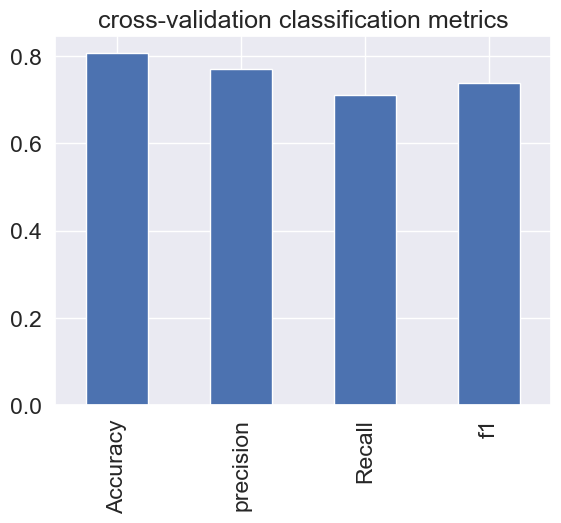

In [78]:
cv_metrics = pd.DataFrame({'Accuracy': cv_acc,
                           'precision': cv_pre,
                           'Recall': cv_re,
                           'f1': cv_f1}, index = [0])
cv_metrics.T.plot.bar(title = 'cross-validation classification metrics', legend = False);

In [79]:
gs_log_reg.best_params_
clf = LogisticRegression(C = 9.236708571873866,
                         solver = 'liblinear')
clf.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,9.236708571873866
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [80]:
# check coef_
clf.coef_

array([[-8.27756977e-01, -2.64285561e+00, -3.17043736e-02,
        -3.12262926e-01, -1.32007340e-01,  2.51450621e-03,
        -2.01559114e-01,  1.78255274e+00,  2.21100722e-01]])

In [81]:
# match the coef's of features to columns
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'PassengerId': np.float64(-0.8277569772764621),
 'Survived': np.float64(-2.6428556104073655),
 'Pclass': np.float64(-0.03170437364729779),
 'Name': np.float64(-0.31226292639025605),
 'Sex': np.float64(-0.1320073403800457),
 'Age': np.float64(0.00251450621086069),
 'SibSp': np.float64(-0.2015591141264214),
 'Parch': np.float64(1.7825527375781152),
 'Ticket': np.float64(0.2211007217435303)}

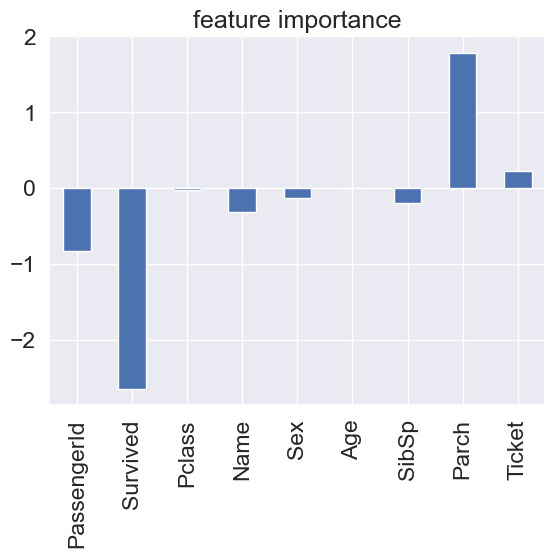

In [82]:
# visualizing feature importance
feature_df = pd.DataFrame(feature_dict, index = [0])
feature_df.T.plot.bar(title = 'feature importance', legend = False);